In [1]:
import os
import random
import time
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image


from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tqdm import tqdm

# ----------------------
# Device
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")



Device: cuda NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
def prepare_mnist_with_grey_dots_cpu(
    mat_path,
    class_ratio=0.5,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42,
    dot_params=None
):
    np.random.seed(seed)

    # --- Load data ---
    data = loadmat(mat_path)
    X = data['data'].T  # (n_samples, 784)
    y = data['label'].flatten()

    # --- Reduce dataset size by class ---
    X_subset, y_subset = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_select = int(len(idx) * class_ratio)
        selected_idx = np.random.choice(idx, n_select, replace=False)
        X_subset.append(X[selected_idx])
        y_subset.append(y[selected_idx])
    X = np.concatenate(X_subset)
    y = np.concatenate(y_subset)

    # --- Shuffle ---
    X, y = shuffle(X, y, random_state=seed)

    # --- Stratified split ---
    train_ratio = split_ratios['train']
    val_ratio = split_ratios['val'] / (split_ratios['val'] + split_ratios['test'])

    X_train, X_rest, y_train, y_rest = train_test_split(
        X, y, train_size=train_ratio, stratify=y, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_rest, y_rest, train_size=val_ratio, stratify=y_rest, random_state=seed)

    # --- Add grey dots + record their positions ---
    def add_grey_dots_np(X_np):
        X_mod = X_np.copy().reshape(-1, 28, 28)
        N = X_mod.shape[0]
        dot_locations = []

        # Convert image to strict black-and-white
        X_strict = np.where(X_mod > 50, 255, 0).astype(np.uint8)
        bright_pixels = [np.argwhere(img == 255) for img in X_strict]

        for i in range(N):
            coords = bright_pixels[i]
            if coords.size == 0:
                dot_locations.append(None)
                continue

            # --- Location ---
            if dot_params and dot_params.get('location') is not None:
                y_dot, x_dot = dot_params['location']
            else:
                y_dot, x_dot = coords[np.random.randint(len(coords))]

            # --- Radius (size) ---
            if dot_params and dot_params.get('radius') is not None:
                radius = int(dot_params['radius'])
            else:
                radius = np.random.randint(1, 3)

            # --- Intensity ---
            if dot_params and dot_params.get('gray') is not None:
                gray = int(dot_params['gray'])
            else:
                gray = np.random.randint(100, 181)

            # --- Apply circular grey dot ---
            y_min = max(y_dot - radius, 0)
            y_max = min(y_dot + radius, 27)
            x_min = max(x_dot - radius, 0)
            x_max = min(x_dot + radius, 27)

            ys, xs = np.ogrid[y_min:y_max+1, x_min:x_max+1]
            dist_sq = (ys - y_dot)**2 + (xs - x_dot)**2
            mask = dist_sq <= radius**2

            X_mod[i, y_min:y_max+1, x_min:x_max+1][mask] = gray

            # Save location
            dot_locations.append({
                'y': int(y_dot),
                'x': int(x_dot),
                'radius': int(radius),
                'gray': int(gray)
            })

        return X_mod.reshape(-1, 784).astype(np.uint8), dot_locations
    # --- Save original images before modifying ---
    X_train_orig = X_train.copy()
    X_val_orig   = X_val.copy()
    X_test_orig  = X_test.copy()
    # Apply grey dot addition
    X_train, dots_train = add_grey_dots_np(X_train)
    X_val, dots_val = add_grey_dots_np(X_val)
    X_test, dots_test = add_grey_dots_np(X_test)

    # Return dictionary with original images added
    return {
        'train': {'X': X_train, 'X_orig': X_train_orig, 'y': y_train, 'dots': dots_train},
        'val':   {'X': X_val,   'X_orig': X_val_orig,   'y': y_val,   'dots': dots_val},
        'test':  {'X': X_test,  'X_orig': X_test_orig,  'y': y_test,  'dots': dots_test}
    }


In [3]:
class InMemoryMNISTDataset(Dataset):
    def __init__(self, X, y, dots=None, X_orig=None, transform=None,
                 return_dot_info=False, return_index=False, return_orig=False):
        self.X = X
        self.y = y
        self.dots = dots
        self.X_orig = X_orig
        self.transform = transform
        self.return_dot_info = return_dot_info
        self.return_index = return_index
        self.return_orig = return_orig

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        # --- Original image ---
        image_orig = self.X_orig[idx] if self.X_orig is not None else None

        # --- Ensure shape ---
        if image.ndim == 1:
            image = image.reshape(28, 28)
        if image_orig is not None and image_orig.ndim == 1:
            image_orig = image_orig.reshape(28, 28)

        # --- Convert to PIL ---
        image = transforms.functional.to_pil_image(image)
        if image_orig is not None:
            image_orig = transforms.functional.to_pil_image(image_orig)

        if self.transform:
            image = self.transform(image)
            if image_orig is not None:
                # Optionally transform original the same way
                image_orig = self.transform(image_orig)

        # --- Build output tuple ---
        out = [image, label]
        if self.return_orig and image_orig is not None:
            out.append(image_orig)
        if self.return_dot_info and self.dots is not None:
            out.append(self.dots[idx])
        if self.return_index:
            out.append(idx)

        return tuple(out)


In [4]:
# ============================================
# Load MNIST with optional grey dot anomalies
# ============================================
splits = prepare_mnist_with_grey_dots_cpu(
    mat_path="/home/blayne/mnist-original.mat",
    class_ratio=0.7,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42
)

# ============================================
# Define transforms
# ============================================
base_transform = transforms.Compose([
    #transforms.RandomRotation(15),
    #transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================
# Wrap into PyTorch Datasets (with original images)
# ============================================

train_dataset = InMemoryMNISTDataset(
    X=splits['train']['X'],
    X_orig=splits['train']['X_orig'],      # <-- original images
    y=splits['train']['y'],
    dots=splits['train']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True                        # <-- return original image
)

val_dataset = InMemoryMNISTDataset(
    X=splits['val']['X'],
    X_orig=splits['val']['X_orig'],
    y=splits['val']['y'],
    dots=splits['val']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

test_dataset = InMemoryMNISTDataset(
    X=splits['test']['X'],
    X_orig=splits['test']['X_orig'],
    y=splits['test']['y'],
    dots=splits['test']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

# ============================================
# Optimized DataLoaders
# ============================================

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=6, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=128, shuffle=False,
    num_workers=6, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False,
    num_workers=4, pin_memory=False, persistent_workers=False
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 34297, Val: 7349, Test: 7350


In [5]:
def show_sample_images_pair(dataset, num_samples=10):
    """
    Display paired samples from a dataset that returns both (modified, original).

    Top row: modified images (with grey dots)
    Bottom row: original MNIST images
    """
    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(15, 4))

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack modified image and label ---
        image_mod = sample[0]      # modified image (with grey dot)
        label = sample[1]

        # --- Extract original image ---
        image_orig = None
        if len(sample) > 2:
            # Case 1: X_orig stored as a dict
            if isinstance(sample[2], dict) and 'X_orig' in sample[2]:
                image_orig = sample[2]['X_orig']
            else:
                image_orig = sample[2]

        # --- Convert modified image to numpy ---
        if isinstance(image_mod, Image.Image):
            image_mod = np.array(image_mod).astype(np.float32) / 255.0
        elif isinstance(image_mod, torch.Tensor):
            image_mod = image_mod.squeeze().cpu().numpy()

        # --- Convert original image to numpy ---
        if image_orig is not None:
            if isinstance(image_orig, Image.Image):
                image_orig = np.array(image_orig).astype(np.float32) / 255.0
            elif isinstance(image_orig, torch.Tensor):
                image_orig = image_orig.squeeze().cpu().numpy()
            elif isinstance(image_orig, np.ndarray):
                image_orig = image_orig.astype(np.float32)
            else:
                # fallback: convert to array if possible
                try:
                    image_orig = np.array(image_orig).astype(np.float32)
                except:
                    raise TypeError(f"Unsupported type for original image: {type(image_orig)}")

        # --- Plot modified (top row) ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(image_mod, cmap='gray', vmin=0, vmax=1)
        plt.title(f"Modified {idx}")
        plt.axis("off")

        # --- Plot original (bottom row) ---
        if image_orig is not None:
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.imshow(image_orig, cmap='gray', vmin=0, vmax=1)
            plt.title(f"Original {idx}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


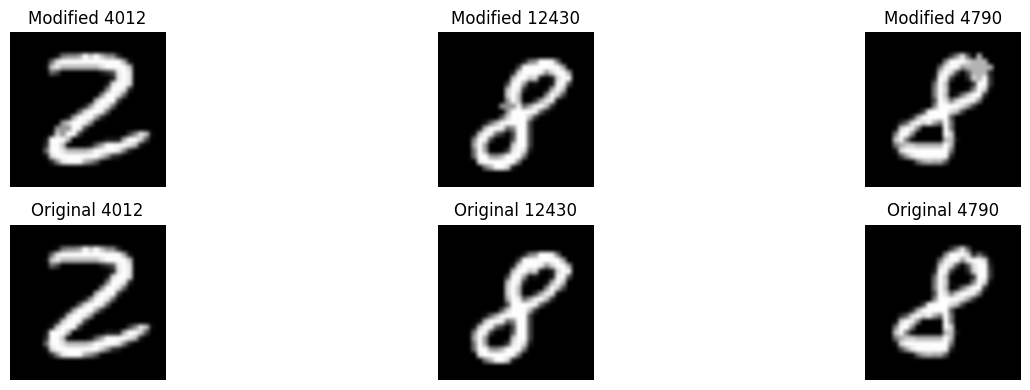

In [6]:
show_sample_images_pair(train_dataset, num_samples=3)
# Example usage:


In [7]:
def show_sample_images_2(dataset, num_samples=10, title='Modified Images'):
    plt.figure(figsize=(num_samples * 1.5, 2))
    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # Defensive unpacking
        img = sample[0]
        label = sample[1]
        image_orig = sample[2] if len(sample) > 2 else None
        dot_info = sample[3] if len(sample) > 3 else None
        sample_idx = sample[4] if len(sample) > 4 else None

        if isinstance(img, torch.Tensor):
            img = img.squeeze().numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')

        # Overlay the anomaly location (scaled)
        if dot_info is not None:
            scale = img.shape[0] / 28  # dynamic scale
            y = dot_info['y'] * scale
            x = dot_info['x'] * scale
            radius = dot_info['radius'] * scale / 2
            plt.scatter(x, y, s=(radius * 8)**2, edgecolor='red', facecolor='none', linewidths=1.5)

        plt.axis('off')
        plt.title(str(int(label)), fontsize=10)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

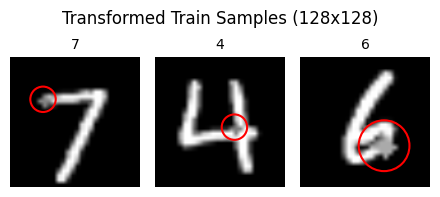

In [8]:
show_sample_images_2(train_dataset, num_samples=3, title="Transformed Train Samples (128x128)")

In [9]:
def random_mask_v5_opt1(
    x, 
    grey_dot_coords=None,
    mask_ratio=0.5,      
    patch_size=8, 
    block_size=3,      
    threshold=0.01, 
    dot_space='28',     # <---- new
    debug=False
):
    B, C, H, W = x.shape
    masks = torch.ones_like(x)
    n_h, n_w = H // patch_size, W // patch_size

    for b in range(B):
        # --- Use stored grey dot info if available ---
        if grey_dot_coords is not None and b < len(grey_dot_coords) and grey_dot_coords[b] is not None:
            info = grey_dot_coords[b]
            y_dot = info.get('y', None)
            x_dot = info.get('x', None)
            radius = info.get('radius', 2)

            # --- Convert to scalar if needed ---
            def to_scalar(val):
                if isinstance(val, (np.ndarray, torch.Tensor)):
                    return int(val.flatten()[0])
                else:
                    return int(val)
            y_dot = to_scalar(y_dot)
            x_dot = to_scalar(x_dot)
            radius = to_scalar(radius)
        else:
            # fallback: random patch
            y_dot = np.random.randint(H)
            x_dot = np.random.randint(W)
            radius = 2

        # --- Scale coordinates only if they’re from 28x28 space ---
        if dot_space == '28':
            scale = H / 28
            y_dot = int(y_dot * scale)
            x_dot = int(x_dot * scale)

        # --- Mask patch block around dot ---
        patch_y = y_dot // patch_size
        patch_x = x_dot // patch_size
        half_block = block_size // 2
        start_y = max(0, patch_y - half_block)
        end_y = min(n_h, patch_y + half_block + 1)
        start_x = max(0, patch_x - half_block)
        end_x = min(n_w, patch_x + half_block + 1)
        
        h_start, h_end = start_y * patch_size, end_y * patch_size
        w_start, w_end = start_x * patch_size, end_x * patch_size

        masks[b, :, h_start:h_end, w_start:w_end] = 0

        if debug:
            print(f"[Batch {b}] dot=({y_dot},{x_dot}), mask block y=({h_start}:{h_end}), x=({w_start}:{w_end})")

    return x * masks, masks


In [10]:
def show_sample_with_mask(dataset, mask_fn, num_samples=5, patch_size=16, title="Masked Images", debug=False):
    """
    Display images from the dataset with a mask applied around grey-dot anomalies.

    Args:
        dataset: InMemoryMNISTDataset instance
        mask_fn: function(x, grey_dot_coords, patch_size, debug) -> masked_x, mask
        num_samples: number of images to display
        patch_size: size of the square patch to mask
        title: figure title
        debug: if True, print debug info from mask_fn
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    plt.figure(figsize=(num_samples * 3, 3))

    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack sample ---
        img        = sample[0]
        label      = sample[1]
        dot_info   = sample[3] if len(sample) > 3 else None

        # --- Convert to tensor with batch dimension ---
        if isinstance(img, np.ndarray):
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
        elif isinstance(img, torch.Tensor):
            img_tensor = img.unsqueeze(0) if img.ndim == 3 else img.unsqueeze(0).unsqueeze(0)
        img_tensor = img_tensor.to(device)

        # --- Prepare grey-dot dict for masking ---
        dot_dict = dot_info if isinstance(dot_info, dict) else None

        # --- Apply mask function ---
        masked_img, _ = mask_fn(
            img_tensor,
            grey_dot_coords=[dot_dict],
            patch_size=patch_size,
            debug=debug
        )

        # --- Convert to CPU numpy for plotting ---
        img_np = img_tensor[0, 0].cpu().numpy()
        masked_np = masked_img[0, 0].cpu().numpy()

        # --- Plot original image ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')

        # --- Plot masked image ---
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(masked_np, cmap='gray')
        plt.axis('off')

        # --- Overlay smaller red circle ---
        if dot_dict is not None:
            scale = img_np.shape[0] / 28
            y = dot_dict['y'] * scale
            x = dot_dict['x'] * scale
            radius = 1.5  # smaller radius for visualization

            plt.subplot(2, num_samples, i + 1)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


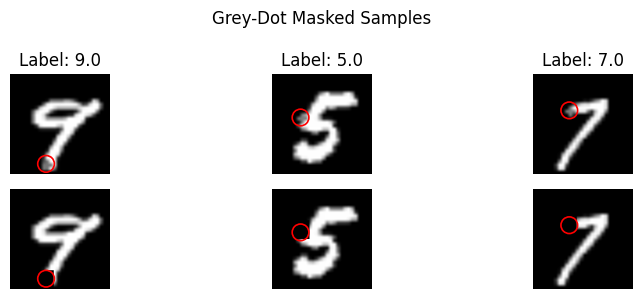

In [11]:
show_sample_with_mask(train_dataset, random_mask_v5_opt1, num_samples=3, patch_size=8, title="Grey-Dot Masked Samples")

In [12]:
class UNet(nn.Module):
    def __init__(self, 
                 in_channels=1, 
                 out_channels=1, 
                 base_channels=32, 
                 num_layers=4, 
                 dropout=0.1, 
                 use_batchnorm=True):
        super().__init__()
        self.num_layers = num_layers
        self.use_batchnorm = use_batchnorm
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.dropout = dropout

        # --- Encoder: stronger first layer ---
        self.encoder.append(nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels, base_channels, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels, base_channels, 3, stride=1, padding=1),  # extra conv
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(base_channels) if use_batchnorm else nn.Identity(),
            nn.Dropout2d(0.05) if dropout > 0 else nn.Identity()
        ))

        # --- Encoder rest of layers ---
        for i in range(1, num_layers):
            in_ch = base_channels * 2**(i-1)
            out_ch = base_channels * 2**i
            self.encoder.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_ch) if use_batchnorm else nn.Identity(),
                nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
            ))

        # --- Decoder ---
        for i in range(num_layers - 1):
            in_ch = base_channels * 2**(num_layers - i - 1)
            out_ch = base_channels * 2**(num_layers - i - 2)
            self.decoder.append(nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2, padding=1, output_padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_ch) if use_batchnorm else nn.Identity(),
                nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
                nn.Conv2d(out_ch, out_ch, 1)  # lightweight 1x1 conv for better reconstruction
            ))

        # Final conv: output 1 channel
        self.final_conv = nn.Conv2d(base_channels, out_channels, 1)

    def forward(self, x):
        enc_feats = []

        # Encoder forward
        for layer in self.encoder:
            x = layer(x)
            enc_feats.append(x)

        # Decoder forward with scaled skip addition
        for i, layer in enumerate(self.decoder):
            x = layer(x)
            skip = enc_feats[-(i + 2)]
            if x.shape[2:] != skip.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:])
            # scaled addition skip
            x = x + 0.5 * skip

        return self.final_conv(x)


In [13]:
"""class UNet(nn.Module):
    def __init__(self, 
                 in_channels=1, 
                 out_channels=1, 
                 base_channels=32, 
                 num_layers=4, 
                 dropout=0.1, 
                 use_batchnorm=True):
        super().__init__()
        self.num_layers = num_layers
        self.use_batchnorm = use_batchnorm
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.dropout = dropout

        # --- Encoder ---
        self.encoder.append(nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels, base_channels, 3, stride=1, padding=1),  # extra conv
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(base_channels) if use_batchnorm else nn.Identity(),
            nn.Dropout2d(0.05) if dropout > 0 else nn.Identity()  # tiny dropout
        ))

        for i in range(1, num_layers):
            in_ch = base_channels * 2**(i-1)
            out_ch = base_channels * 2**i
            self.encoder.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_ch) if use_batchnorm else nn.Identity()
            ))

        # --- Decoder ---
        for i in range(num_layers - 1):
            in_ch = base_channels * 2**(num_layers - i - 1)
            out_ch = base_channels * 2**(num_layers - i - 2)
            self.decoder.append(nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2, padding=1, output_padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_ch) if use_batchnorm else nn.Identity(),
                nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
            ))

        # Final conv: output 1 channel
        self.final_conv = nn.Conv2d(base_channels, out_channels, 1)

    def forward(self, x):
        enc_feats = []

        # Encoder forward
        for layer in self.encoder:
            x = layer(x)
            enc_feats.append(x)

        # Decoder forward with scaled skip addition
        for i, layer in enumerate(self.decoder):
            x = layer(x)
            skip = enc_feats[-(i + 2)]
            if x.shape[2:] != skip.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:])
            x = x + 0.5 * skip  # scale skip to prevent feature explosion

        return self.final_conv(x)
"""

'class UNet(nn.Module):\n    def __init__(self, \n                 in_channels=1, \n                 out_channels=1, \n                 base_channels=32, \n                 num_layers=4, \n                 dropout=0.1, \n                 use_batchnorm=True):\n        super().__init__()\n        self.num_layers = num_layers\n        self.use_batchnorm = use_batchnorm\n        self.encoder = nn.ModuleList()\n        self.decoder = nn.ModuleList()\n        self.dropout = dropout\n\n        # --- Encoder ---\n        self.encoder.append(nn.Sequential(\n            nn.Conv2d(in_channels, base_channels, 3, stride=1, padding=1),\n            nn.ReLU(inplace=True),\n            nn.Conv2d(base_channels, base_channels, 3, stride=1, padding=1),  # extra conv\n            nn.ReLU(inplace=True),\n            nn.BatchNorm2d(base_channels) if use_batchnorm else nn.Identity(),\n            nn.Dropout2d(0.05) if dropout > 0 else nn.Identity()  # tiny dropout\n        ))\n\n        for i in range(1, num

In [14]:
def masked_reconstruction_loss(pred, target, mask, reduction='mean'):
    """
    Compute MSE loss only on the masked regions.

    Parameters:
    -----------
    pred : torch.Tensor
        Model output (B, C, H, W)
    target : torch.Tensor
        Ground truth image (B, C, H, W)
    mask : torch.Tensor
        Binary mask where 1 = visible, 0 = masked
    reduction : str
        'mean' or 'sum'

    Returns:
    --------
    loss : torch.Tensor
        The masked MSE loss
    """
    # Invert mask to focus on masked regions
    masked_mse = ((pred - target) ** 2) * (1 - mask)

    if reduction == 'mean':
        # Avoid division by zero if no masked pixels
        return masked_mse.sum() / (1e-8 + (1 - mask).sum())
    elif reduction == 'sum':
        return masked_mse.sum()
    else:
        return masked_mse

In [15]:
# -------------------------------------------------
# Training + Evaluation Function (adapted)
# -------------------------------------------------
def train_and_evaluate(
    model, train_loader, val_loader,
    n_epochs=10, mask_ratio=0.3, lr=1e-3,
    patience=10, mask_fn=None, patch_size=None,
    block_size=None,
    show_batch_progress=True
):
    """
    Train the model with masked reconstruction loss and early stopping.
    Designed for datasets with grey_dot_coords and masked regions.
    """
    if mask_fn is None:
        raise ValueError("You must provide a masking function (mask_fn).")

    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # -------------------
        # Training
        # -------------------
        model.train()
        total_train_loss = 0
        epoch_start = time.time()

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} - Training", leave=False) \
                     if show_batch_progress else train_loader

        for batch in train_iter:
            # --- Extract images and grey_dot_coords safely ---
            if len(batch) >= 3:
                x, _, dot_info = batch[:3]
            else:
                x = batch[0]
                dot_info = [None] * x.size(0)

            B = x.size(0)
            grey_dot_coords = []
            for i in range(B):
                if isinstance(dot_info, dict):
                    grey_dot_coords.append(dot_info)
                elif isinstance(dot_info, (list, tuple)):
                    di = dot_info[i] if i < len(dot_info) else None
                    grey_dot_coords.append(di if isinstance(di, dict) else None)
                else:
                    grey_dot_coords.append(None)

            x = x.to(device)
            x_masked, mask = mask_fn(
                x,
                grey_dot_coords=grey_dot_coords,
                mask_ratio=mask_ratio,
                patch_size=patch_size,
                block_size=block_size
            )

            x_rec = model(x_masked)
            loss = masked_reconstruction_loss(x_rec, x, mask, reduction='mean')

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * B
            if show_batch_progress:
                train_iter.set_postfix({"batch_loss": f"{loss.item():.6f}"})

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # -------------------
        # Validation
        # -------------------
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) >= 3:
                    x, _, dot_info = batch[:3]
                else:
                    x = batch[0]
                    dot_info = [None] * x.size(0)

                B = x.size(0)
                grey_dot_coords = []
                for i in range(B):
                    if isinstance(dot_info, dict):
                        grey_dot_coords.append(dot_info)
                    elif isinstance(dot_info, (list, tuple)):
                        di = dot_info[i] if i < len(dot_info) else None
                        grey_dot_coords.append(di if isinstance(di, dict) else None)
                    else:
                        grey_dot_coords.append(None)

                x = x.to(device)
                x_masked, mask = mask_fn(
                    x,
                    grey_dot_coords=grey_dot_coords,
                    mask_ratio=mask_ratio,
                    patch_size=patch_size,
                    block_size=block_size
                )

                x_rec = model(x_masked)
                loss = masked_reconstruction_loss(x_rec, x, mask, reduction='mean')
                total_val_loss += loss.item() * B

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        epoch_time = time.time() - epoch_start
       # print(f"Epoch {epoch+1}/{n_epochs} | "
        #      f"Train Loss: {avg_train_loss:.6f} | "
         #     f"Val Loss: {avg_val_loss:.6f} | "
          #    f"Time: {epoch_time:.1f}s")

        # -------------------
        # Early Stopping
        # -------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return best_val_loss, train_losses, val_losses


=== Training | mask_fn=random_mask_v5_opt1, epochs=15, mask=0.2, lr=0.0001, patch_size=4, block_size=3 ===


Time for this run: 1152.06 seconds
Test MSE: 0.057646


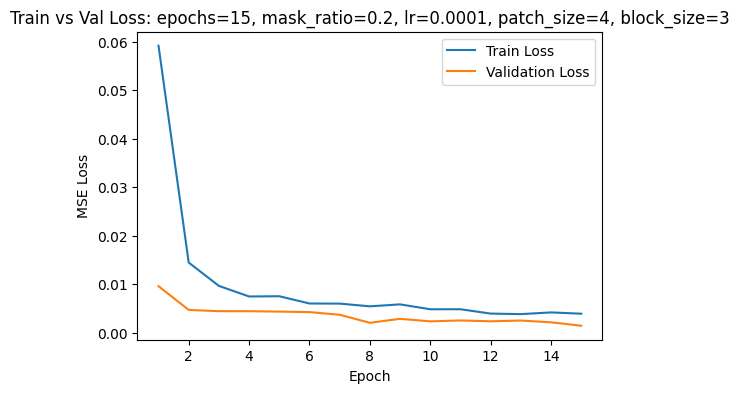

In [16]:
# --- Hyperparameter sweep ---
epoch_options      = [15]                # Number of training epochs
mask_options       = [0.2]               # Masking ratio
lr_options         = [0.0001] # Learning rates used
patch_size_options = [4]              # Size of mask patches (pixels)
block_size_options = [3]           # Block sizes for block-style masking (pixels)"""



mask_fn_options = [
    ("random_mask_v5_opt1", random_mask_v5_opt1),
]

results = []
train_val_curves = {}
test_results = []

# -------------------------------------------------
# Helper function to extract batch elements robustly
# -------------------------------------------------
def extract_batch_with_orig(batch):
    """
    Return:
      x: tensor (B, C, H, W) — the dataset image (with grey dot present)
      x_orig: tensor or None (B, C, H, W) — original image without dot if available
      grey_dot_coords: list of dicts or None per item
    """
    # Cases:
    # - If dataset returned only (x, y)
    # - If dataset returned (x, y, x_orig, dot_info, idx) or similar.
    if len(batch) == 2:
        x, _ = batch
        x_orig = None
        grey_dot_coords = [None] * x.size(0)
    else:
        # batch may be length >=3
        x = batch[0]
        # try to find x_orig and dot_info robustly
        # typical order in your Dataset: (image, label, image_orig, dots, index)
        x_orig = None
        dot_info = None

        # pick plausible positions
        if len(batch) >= 3:
            # third item could be x_orig or dot_info
            third = batch[2]
            if isinstance(third, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = third
            elif isinstance(third, dict) or isinstance(third, (list, tuple)):
                dot_info = third

        if len(batch) >= 4:
            fourth = batch[3]
            if x_orig is None and isinstance(fourth, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = fourth
            elif dot_info is None and (isinstance(fourth, dict) or isinstance(fourth, (list, tuple))):
                dot_info = fourth

        # Build grey_dot_coords list
        B = x.size(0)
        if dot_info is None:
            grey_dot_coords = [None] * B
        elif isinstance(dot_info, dict) and all(isinstance(dot_info.get(k), torch.Tensor) for k in ("y", "x")):
            # batched dict of tensors
            n = dot_info["y"].numel()
            grey_dot_coords = [
                {
                    "y": int(dot_info["y"][i].item()),
                    "x": int(dot_info["x"][i].item()),
                    "radius": int(dot_info.get("radius", torch.tensor(1))[i].item()) if "radius" in dot_info else 1
                }
                for i in range(n)
            ]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None] * (B - len(grey_dot_coords))
        elif isinstance(dot_info, (list, tuple)):
            grey_dot_coords = [di if isinstance(di, dict) else None for di in dot_info]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None] * (B - len(grey_dot_coords))
        else:
            # maybe a single dict repeated for whole batch
            if isinstance(dot_info, dict):
                grey_dot_coords = [dot_info] + [None] * (B - 1)
            else:
                grey_dot_coords = [None] * B

        # If x_orig is a single tensor for the whole batch (rare), expand it
        if x_orig is not None and isinstance(x_orig, torch.Tensor) and x_orig.shape[0] != x.shape[0]:
            # try to tile or broadcast if necessary
            try:
                x_orig = x_orig.repeat(x.shape[0], *([1] * (x_orig.dim() - 1)))
            except:
                x_orig = None

    return x, x_orig, grey_dot_coords

# ======================================================
# Main training + evaluation sweep
# ======================================================
for mask_fn_name, mask_fn in mask_fn_options:
    for n_epoch in epoch_options:
        for mask_ratio in mask_options:
            for lr in lr_options:
                for patch_size in patch_size_options:
                    for block_size in block_size_options:
                        print("\n" + "=" * 60, flush=True)
                        print(f"=== Training | mask_fn={mask_fn_name}, epochs={n_epoch}, "
                              f"mask={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size} ===", flush=True)

                        start_time = time.time()

                        # Instantiate a fresh model
                        model_copy = UNet(in_channels=1, out_channels=1, base_channels=32, num_layers=4).to(device)


                        # Train and evaluate
                        best_val_loss, train_losses, val_losses = train_and_evaluate(
                            model_copy, train_loader, val_loader,
                            n_epochs=n_epoch,
                            mask_ratio=mask_ratio,
                            lr=lr,
                            patience=10,
                            mask_fn=mask_fn,
                            patch_size=patch_size,
                            block_size=block_size
                        )

                        elapsed = time.time() - start_time
                        print(f"Time for this run: {elapsed:.2f} seconds", flush=True)

                        # Store results
                        results.append({
                            "mask_fn": mask_fn_name,
                            "n_epochs": n_epoch,
                            "mask_ratio": mask_ratio,
                            "lr": lr,
                            "patch_size": patch_size,
                            "block_size": block_size,
                            "val_loss": best_val_loss,
                            "train_time_s": elapsed
                        })
                        train_val_curves[(n_epoch, mask_ratio, lr, patch_size, block_size)] = (train_losses, val_losses)

                        # ======================================================
                        # Test set evaluation
                        # ======================================================
                        model_copy.eval()
                        mse_loss = nn.MSELoss()
                        test_mse = 0.0

                        with torch.no_grad():
                            for batch in test_loader:
                                x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                                x = x.to(device)

                                x_masked, mask = mask_fn(
                                    x,
                                    grey_dot_coords=grey_dot_coords,
                                    mask_ratio=mask_ratio,
                                    patch_size=patch_size,
                                    block_size=block_size
                                )
                                x_rec = model_copy(x_masked)
                                loss = mse_loss(x_rec * mask, x * mask)
                                test_mse += loss.item() * x.size(0)

                        test_mse /= len(test_loader.dataset)
                        print(f"Test MSE: {test_mse:.6f}")
    
                        # ======================================================
                        # Visual comparison
                        # ======================================================
                        """
                        with torch.no_grad():
                            batch = next(iter(test_loader))
                            x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                            x = x.to(device)
                            x_orig_t = x_orig.to(device) if x_orig is not None else None

                            x_masked, mask = mask_fn(
                                x,
                                grey_dot_coords=grey_dot_coords,
                                mask_ratio=mask_ratio,
                                patch_size=patch_size,
                                block_size=block_size
                            )
                            x_rec = model_copy(x_masked)

                        n_show = 3
                        plt.figure(figsize=(12, 8))

                        for i in range(n_show):
                            orig_np = x_orig_t[i, 0].cpu().numpy() if x_orig_t is not None else x[i, 0].cpu().numpy()
                            img_with_dot_np = x[i, 0].cpu().numpy()
                            masked_np = x_masked[i, 0].cpu().numpy()
                            rec_np = x_rec[i, 0].cpu().numpy()
                            mask_np = (mask[i, 0].cpu().numpy() > 0.5).astype(np.float32)
                            filled = masked_np * mask_np + rec_np * (1.0 - mask_np)

                            # Original
                            plt.subplot(4, n_show, i + 1)
                            plt.imshow(orig_np, cmap='gray', vmin=0, vmax=1)
                            plt.title("Original (no dot)")
                            plt.axis("off")

                            # Image with grey dot
                            plt.subplot(4, n_show, i + 1 + n_show)
                            plt.imshow(img_with_dot_np, cmap='gray', vmin=0, vmax=1)
                            plt.title("Image (with grey dot)")
                            plt.axis("off")

                            # Overlay dot marker if available
                            if grey_dot_coords is not None and i < len(grey_dot_coords) and grey_dot_coords[i] is not None:
                                info = grey_dot_coords[i]
                                if info.get('y') is not None and info.get('x') is not None:
                                    H = img_with_dot_np.shape[0]
                                    scale = H / 28.0
                                    y = int(info['y'] * scale)
                                    x_ = int(info['x'] * scale)
                                    plt.scatter(x_, y, s=80, edgecolors='red', facecolors='none', linewidths=1.2)
                            # Masked input
                            plt.subplot(4, n_show, i + 1 + 2 * n_show)
                            plt.imshow(masked_np, cmap='gray', vmin=0, vmax=1)
                            plt.title("Masked Input (with dot)")
                            plt.axis("off")

                            # Reconstruction
                            plt.subplot(4, n_show, i + 1 + 3 * n_show)
                            plt.imshow(filled, cmap='gray', vmin=0, vmax=1)
                            plt.title("Reconstructed (filled)")
                            plt.axis("off")

                        plt.tight_layout()
                        plt.show()
"""
# ======================================================
# Results summary and plotsfrom unet to de
# ======================================================
df_val = pd.DataFrame(results)

for key, (train_losses, val_losses) in train_val_curves.items():
    n_epoch, mask_ratio, lr, patch_size, block_size = key
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.title(f"Train vs Val Loss: epochs={n_epoch}, mask_ratio={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()


In [20]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def evaluate_masked_vae_with_visuals(
    model,
    dataloader,
    mask_fn,
    device,
    patch_size=8,
    n_show=5
):
    """
    Evaluate masked VAE on the test set with visuals:
      - Original (no dot) image with mask box
      - Image with grey dot
      - Reconstructed (filled) image
      - Zoomed-in view: original vs reconstructed masked region
    """
    model.eval()
    mse_loss = nn.MSELoss(reduction='none')
    all_masked_mse = []

    with torch.no_grad():
        batch = next(iter(dataloader))
        x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)

        x = x.to(device)
        if x_orig is not None:
            x_orig_t = x_orig.to(device)
        else:
            x_orig_t = None

        # Apply mask function
        x_masked, mask = mask_fn(
            x,
            grey_dot_coords=grey_dot_coords,
            mask_ratio=0.4,
            patch_size=patch_size
        )
        x_rec = model(x_masked)

        # Compute masked region MSE
        masked_region = (1.0 - mask)
        mse_per_pixel = mse_loss(x_rec, x)
        masked_mse = (mse_per_pixel * masked_region).sum(dim=(1, 2, 3)) / masked_region.sum(dim=(1, 2, 3))
        all_masked_mse.extend(masked_mse.cpu().numpy())

        # ----- Visualisations -----
        n_show = min(n_show, x.size(0))
        plt.figure(figsize=(20, 3 * n_show))  # wider for 4 panels

        for i in range(n_show):
            if x_orig_t is not None:
                orig_np = x_orig_t[i, 0].cpu().numpy()
            else:
                orig_np = x[i, 0].cpu().numpy()

            img_with_dot_np = x[i, 0].cpu().numpy()
            rec_np = x_rec[i, 0].cpu().numpy()
            mask_np = mask[i, 0].cpu().numpy()
            masked_region_np = (mask_np < 0.5).astype(np.uint8)
            masked_np = x_masked[i, 0].cpu().numpy()

            # Full filled image
            filled = masked_np * mask_np + rec_np * (1.0 - mask_np)

            # --- Mask bounding box ---
            ys, xs = np.where(masked_region_np > 0)
            if len(xs) > 0 and len(ys) > 0:
                y_min, y_max = ys.min(), ys.max()
                x_min, x_max = xs.min(), xs.max()
            else:
                y_min = x_min = 0
                y_max = x_max = masked_region_np.shape[0] - 1

            # -----------------------------
            # 1️⃣ Original (no dot)
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 1)
            plt.imshow(orig_np, cmap='gray', vmin=0, vmax=1)
            plt.plot([x_min, x_max, x_max, x_min, x_min],
                     [y_min, y_min, y_max, y_max, y_min],
                     color='red', linewidth=1.5)
            plt.title(f"Original (no dot)\nMasked MSE={masked_mse[i]:.4f}")
            plt.axis("off")

            # -----------------------------
            # 2️⃣ Image with grey dot
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 2)
            plt.imshow(img_with_dot_np, cmap='gray', vmin=0, vmax=1)
            plt.plot([x_min, x_max, x_max, x_min, x_min],
                     [y_min, y_min, y_max, y_max, y_min],
                     color='red', linewidth=1.5)
            plt.title("Image (with grey dot)")
            plt.axis("off")

            # -----------------------------
            # 3️⃣ Reconstructed (filled)
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 3)
            plt.imshow(filled, cmap='gray', vmin=0, vmax=1)
            plt.plot([x_min, x_max, x_max, x_min, x_min],
                     [y_min, y_min, y_max, y_max, y_min],
                     color='red', linewidth=1.5)
            plt.title("Reconstructed (filled)")
            plt.axis("off")

            # -----------------------------
            # 4️⃣ Zoomed-in: original vs reconstructed
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 4)
            zoom_orig = orig_np[y_min:y_max, x_min:x_max]
            zoom_rec = filled[y_min:y_max, x_min:x_max]
            # combine side-by-side
            zoom_combined = np.concatenate([zoom_orig, zoom_rec], axis=1)
            plt.imshow(zoom_combined, cmap='gray', vmin=0, vmax=1)
            plt.title("Zoom: original | reconstructed")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    mean_mse = np.nanmean(all_masked_mse)
    print(f"Average masked region MSE: {mean_mse:.6f}")
    return mean_mse


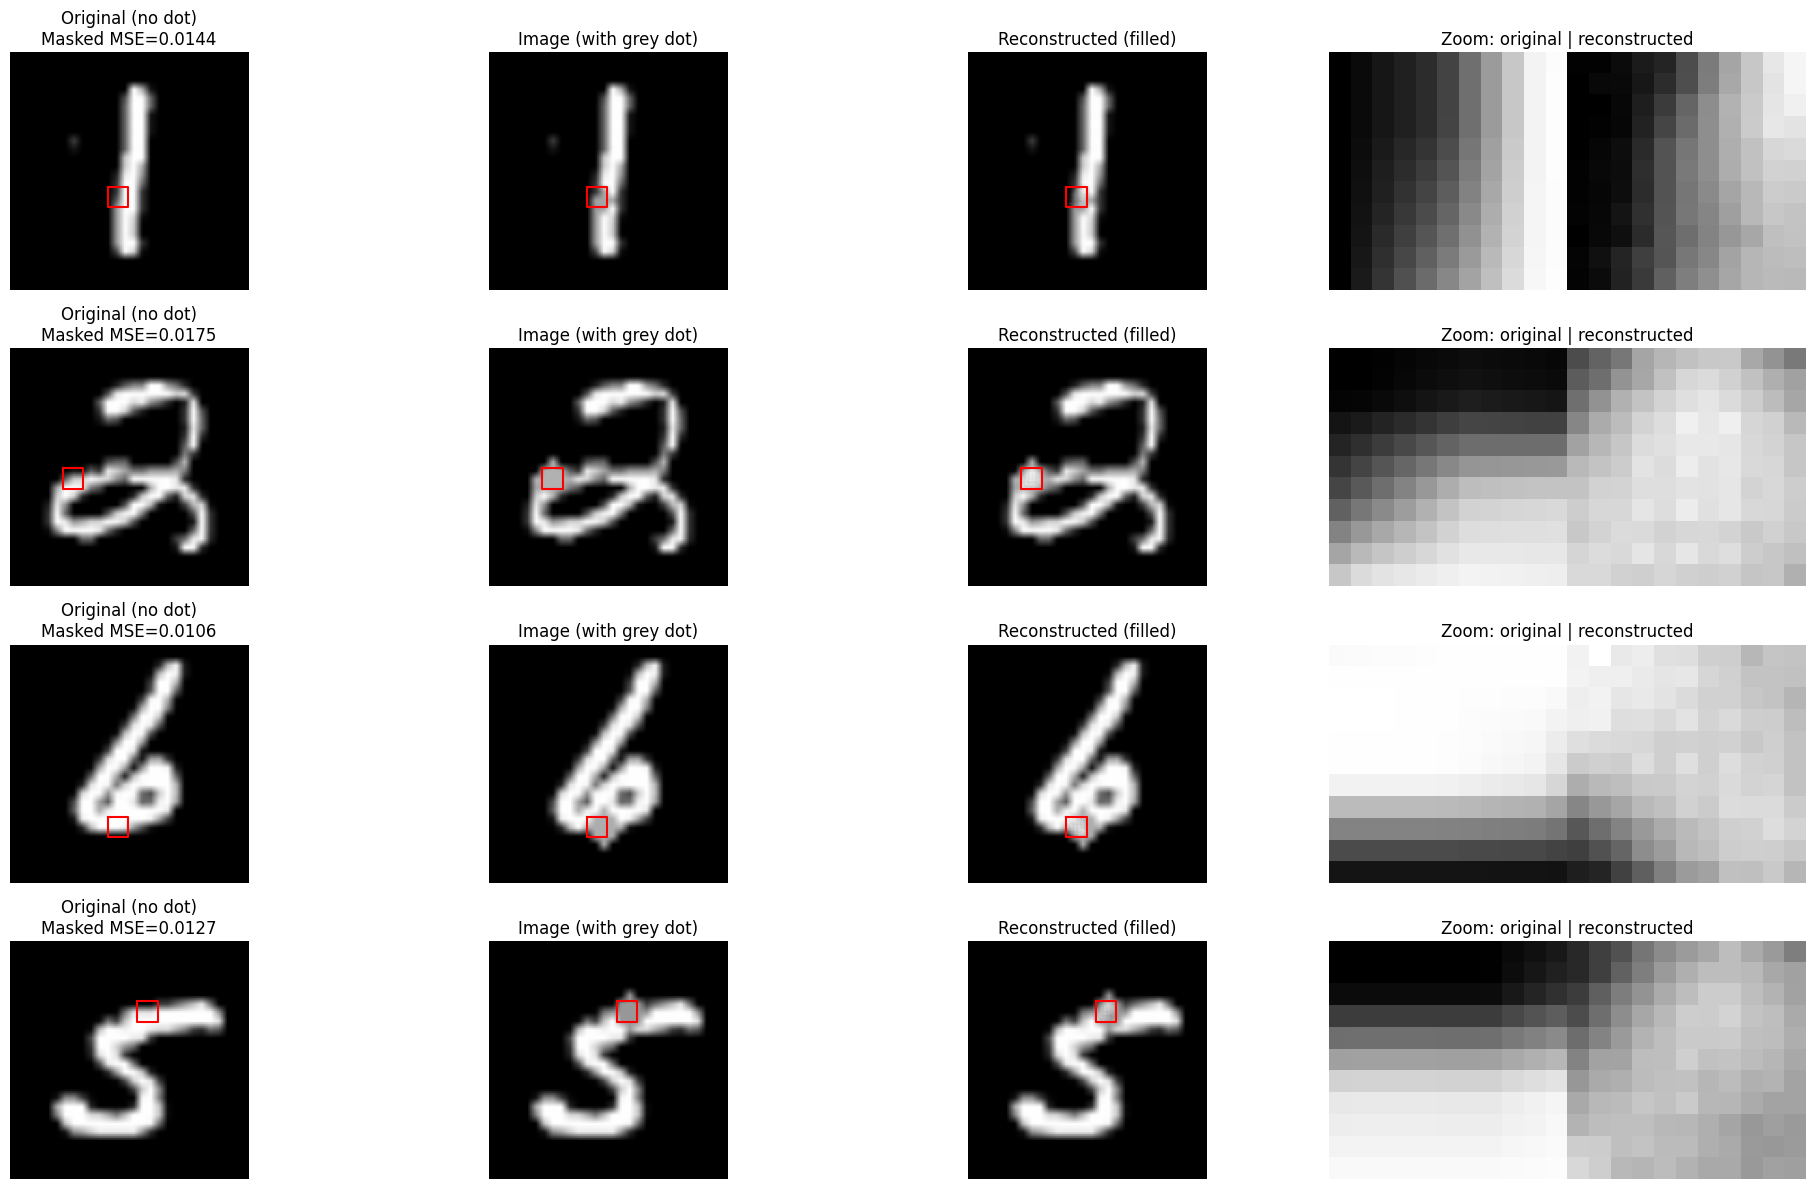

Average masked region MSE: 0.025671


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
masked_mse = evaluate_masked_vae_with_visuals(
    model_copy, test_loader, mask_fn, device=device, patch_size=patch_size, n_show=4
)
